<a href="https://colab.research.google.com/github/2BerbyMarty2/search-algorithms-2026/blob/main/Maze_Search_IDDFS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [2]:
def get_coords(node_id):
    return (node_id // 6, node_id % 6)

def get_node(coords):
    return coords[0] * 6 + coords[1]

In [3]:
def setup_maze():
  start_id = random.randint(0, 11)
  goal_id = random.randint(24, 35)

  all_nodes = list(range(36))
  valid_barriers = [n for n in all_nodes if n!= start_id and n!= goal_id]
  barriers = random.sample(valid_barriers, 4)

  return {
      'start': get_coords(start_id),
      'goal': get_coords(goal_id),
      'barriers': [get_coords(b) for b in barriers]
  }

In [4]:
def draw_maze(maze_coordinates, path=None):
    fig, ax = plt.subplots(figsize=(5, 5))

    labels = range(6)
    centers = np.arange(0.5, 6.0)

    ax.set_xticks(centers)
    ax.set_yticks(centers)
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    ax.set_xticks(range(7), minor=True)
    ax.set_yticks(range(7), minor=True)
    ax.grid(True, which='minor', color='black', linestyle='-')

    ax.tick_params(which='major', length=0)
    ax.xaxis.tick_top()

    ax.invert_yaxis()
    ax.set_xlim(0, 6)
    ax.set_ylim(6, 0)

    # 1. Draw Start, Goal, and Barriers
    ax.add_patch(patches.Rectangle(maze_coordinates['start'], 1, 1, color='green', alpha=0.6, label='Start'))
    ax.add_patch(patches.Rectangle(maze_coordinates['goal'], 1, 1, color='red', alpha=0.6, label='Goal'))

    for barrier_coords in maze_coordinates['barriers']:
        ax.add_patch(patches.Rectangle(barrier_coords, 1, 1, color='black', alpha=0.8))

    # 2. Draw the Path (if provided)
    if path:
        # We need to shift coordinates by 0.5 to draw the line in the CENTER of the boxes
        # path is expected to be a list of IDs or (x,y) tuples
        path_coords = [get_coords(node_id) if isinstance(node_id, int) else node_id for node_id in path]

        path_x = [c[0] + 0.5 for c in path_coords]
        path_y = [c[1] + 0.5 for c in path_coords]

        # Plot the line
        ax.plot(path_x, path_y, color='blue', linewidth=3, marker='o', markersize=5, label='IDDFS Path')

        # Optional: Add an arrow to show direction
        ax.quiver(path_x[:-1], path_y[:-1],
                  np.diff(path_x), np.diff(path_y),
                  scale_units='xy', angles='xy', scale=1, color='blue', alpha=0.3)

    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.show()

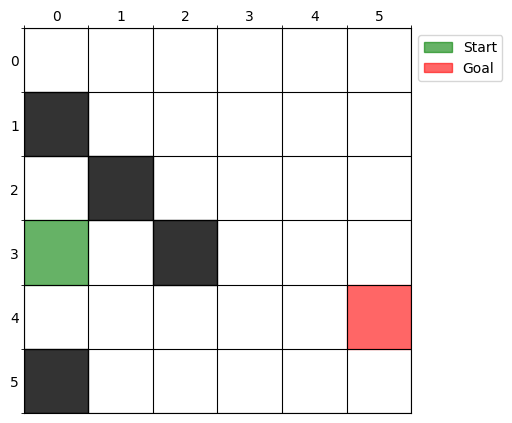

In [5]:
draw_maze(setup_maze())

In [6]:
def get_neighbors(node_id, barriers):
    # Rule (b): Convert current ID to coordinates to find neighbors
    x, y = get_coords(node_id)
    neighbors = []

    # Check all 8 directions (Horizontal, Vertical, Diagonal)
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            if dx == 0 and dy == 0:
                continue

            nx, ny = x + dx, y + dy

            # Rule (c): Stay within 6x6 grid and avoid barriers
            if 0 <= nx < 6 and 0 <= ny < 6:
                # Convert back to ID: ID = x*6 + y (based on your //6 and %6 logic)
                neighbor_id = nx * 6 + ny
                if get_coords(neighbor_id) not in barriers:
                    neighbors.append(neighbor_id)

    # Rule (a): Process neighbors in increasing order of ID
    neighbors.sort()
    return neighbors

(0, 2)
(4, 2)
(0, 1) (0, 3) (1, 1) (1, 2) 

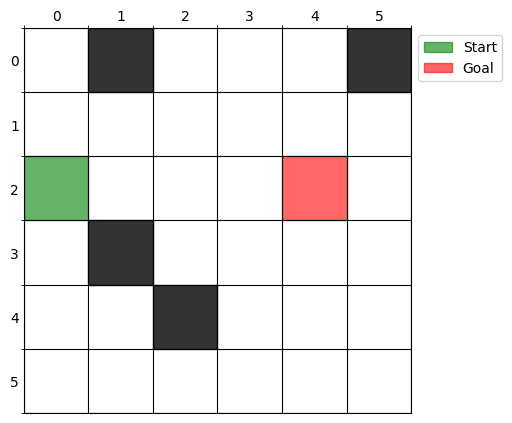

In [7]:
a = setup_maze()

b = get_neighbors(get_node(a['start']), a['barriers'])
print(a['start'])
print(a['goal'])
for i in b:
  print(get_coords(i), end=' ')
draw_maze(a)

In [8]:
def dls(current_id, goal_id, barriers, limit, path, visited_in_iteration):
    # Rule (d): Every node explored adds 1 minute to the total
    visited_in_iteration.append(current_id)

    if current_id == goal_id:
        return path + [current_id]

    if limit <= 0:
        return None

    for neighbor in get_neighbors(current_id, barriers):
        if neighbor not in path: # Standard cycle prevention
            result = dls(neighbor, goal_id, barriers, limit - 1, path + [current_id], visited_in_iteration)
            if result:
                return result
    return None

In [9]:
from matplotlib.artist import get
def run_iddfs(maze_data):
    # Convert start/goal coords back to IDs for the search
    # Based on your get_coords: x = id//6, y = id%6 -> id = x*6 + y
    start_id = get_node(maze_data['start'])
    goal_id = get_node(maze_data['goal'])
    barriers = maze_data['barriers']

    total_visited_nodes = []
    final_path = None

    for depth in range(36): # Maximum possible depth in 6x6 grid
        visited_this_depth = []
        result = dls(start_id, goal_id, barriers, depth, [], visited_this_depth)

        # Rule (d): Total time is the sum of all nodes explored across ALL iterations
        total_visited_nodes.extend(visited_this_depth)

        if result:
            final_path = result
            break

    return total_visited_nodes, final_path

In [10]:
def calculate_path_cost(path):
    cost = 0
    for i in range(len(path) - 1):
        c1 = get_coords(path[i])
        c2 = get_coords(path[i+1])
        # Rule (e): Euclidean distance
        cost += np.sqrt((c1[0]-c2[0])**2 + (c1[1]-c2[1])**2)
    return cost

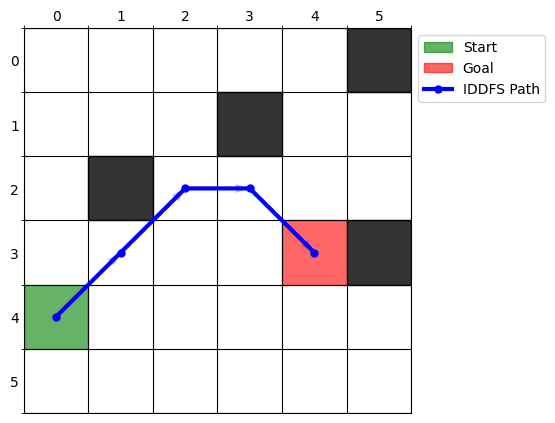

Total Time (Nodes Explored): 376 minutes
Final Path (IDs): [4, 9, 14, 20, 27]
Total Edge Cost: 5.24


In [11]:
maze = setup_maze()
visited, path = run_iddfs(maze)

draw_maze(maze,path)

print(f"Total Time (Nodes Explored): {len(visited)} minutes")
print(f"Final Path (IDs): {path}")
print(f"Total Edge Cost: {calculate_path_cost(path):.2f}")